###

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/raw/hotel_bookings.csv")

print("=" * 50)
print(f"Shape: {df.shape}")
print("=" * 50)

print("\nNull counts (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print(f"\nDuplicates: {df.duplicated().sum()}")

print("\nData types:")
print(df.dtypes)

print("\nNumerical summary:")
print(df.describe().T[["count", "mean", "std", "min", "max"]])

print("\nTarget distribution:")
print(df["is_canceled"].value_counts(normalize=True).rename({0:"not cancelled", 1:"cancelled"}))

Shape: (119390, 32)

Null counts (top 15):
company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
adults                            0
stays_in_week_nights              0
babies                            0
meal                              0
lead_time                         0
dtype: int64

Duplicates: 31994

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                

## 1 — Imports & load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")

df_raw = pd.read_csv("./data/raw/hotel_bookings.csv")
df = df_raw.copy()
print(f"Loaded: {df.shape}")

Loaded: (119390, 32)


## 2 — Clean & fix known issues
python

In [7]:
# Drop leakage column and useless high-null column
#df.drop(columns=["reservation_status", "reservation_status_date", "company"], inplace=True)

# Fill nulls
df["agent"].fillna(0, inplace=True)
df["children"].fillna(0, inplace=True)
df["country"].fillna("Unknown", inplace=True)

# Fix data types
df["agent"] = df["agent"].astype(int)
df["children"] = df["children"].astype(int)
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=["January","February","March","April","May","June",
                "July","August","September","October","November","December"],
    ordered=True
)

# Remove invalid ADR
df = df[df["adr"] >= 0]

# Remove zero-guest bookings (nonsensical)
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]

# Drop duplicates
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {n_before - len(df)} duplicates. Remaining: {len(df)}")

# Create total_nights feature (useful immediately)
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Filter out zero-night stays
df = df[df["total_nights"] > 0]

print(f"Final clean shape: {df.shape}")
df.to_csv("./data/processed/hotel_bookings_clean.csv", index=False)
print("Saved to data/processed/")

Dropped 0 duplicates. Remaining: 86372
Final clean shape: (86372, 30)
Saved to data/processed/


## 3 — Target & class balance

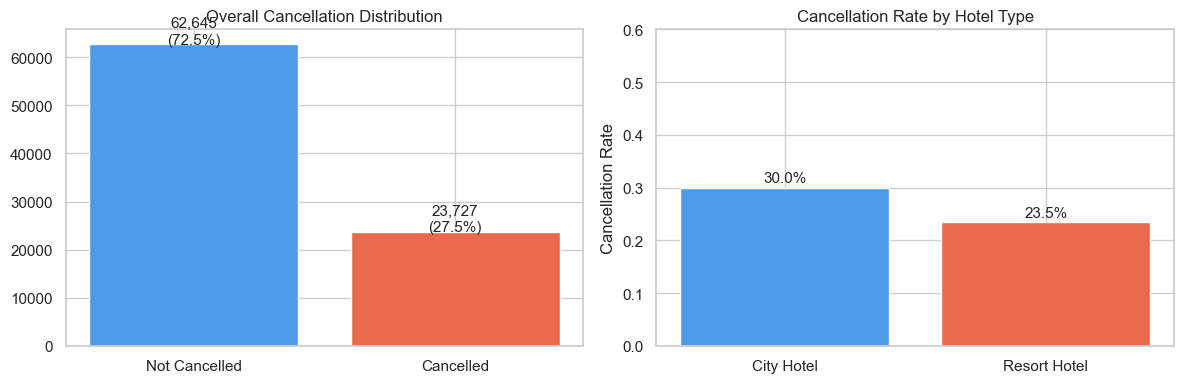

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
counts = df["is_canceled"].value_counts()
axes[0].bar(["Not Cancelled", "Cancelled"], counts.values, color=["#4C9BE8", "#E8694C"])
axes[0].set_title("Overall Cancellation Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=11)

# By hotel type
cancel_by_hotel = df.groupby("hotel")["is_canceled"].mean().reset_index()
axes[1].bar(cancel_by_hotel["hotel"], cancel_by_hotel["is_canceled"], color=["#4C9BE8","#E8694C"])
axes[1].set_title("Cancellation Rate by Hotel Type")
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_ylim(0, 0.6)
for i, row in cancel_by_hotel.iterrows():
    axes[1].text(i, row["is_canceled"] + 0.01, f"{row['is_canceled']:.1%}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("./reports/figures/01_cancellation_distribution.png", dpi=150)
plt.show()

## 4 — Seasonality (Australian framing)

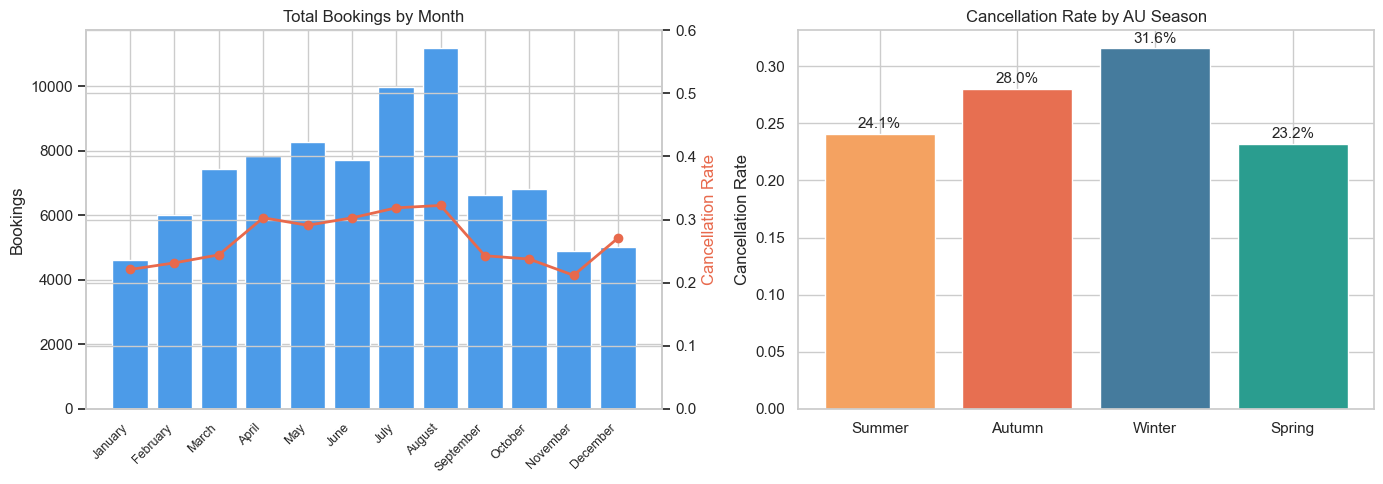

In [11]:
# Map to AU Southern Hemisphere seasons
season_map = {
    "December": "Summer", "January": "Summer", "February": "Summer",
    "March": "Autumn",   "April": "Autumn",   "May": "Autumn",
    "June": "Winter",    "July": "Winter",     "August": "Winter",
    "September": "Spring","October": "Spring", "November": "Spring"
}
df["au_season"] = df["arrival_date_month"].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bookings by month
monthly = df.groupby("arrival_date_month", observed=True).agg(
    total=("is_canceled","count"),
    cancel_rate=("is_canceled","mean")
).reset_index()

ax1 = axes[0]
bars = ax1.bar(range(12), monthly["total"], color="#4C9BE8")
ax1.set_xticks(range(12))
ax1.set_xticklabels(monthly["arrival_date_month"], rotation=45, ha="right", fontsize=9)
ax1.set_title("Total Bookings by Month")
ax1.set_ylabel("Bookings")

ax2 = ax1.twinx()
ax2.plot(range(12), monthly["cancel_rate"], color="#E8694C", marker="o", linewidth=2)
ax2.set_ylabel("Cancellation Rate", color="#E8694C")
ax2.set_ylim(0, 0.6)

# By AU season
season_order = ["Summer","Autumn","Winter","Spring"]
season_data = df.groupby("au_season")["is_canceled"].mean().reindex(season_order)
axes[1].bar(season_order, season_data.values, color=["#F4A261","#E76F51","#457B9D","#2A9D8F"])
axes[1].set_title("Cancellation Rate by AU Season")
axes[1].set_ylabel("Cancellation Rate")
for i, v in enumerate(season_data.values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("./reports/figures/02_seasonality.png", dpi=150)
plt.show()

## 5 — Lead time vs cancellation (key predictive signal)

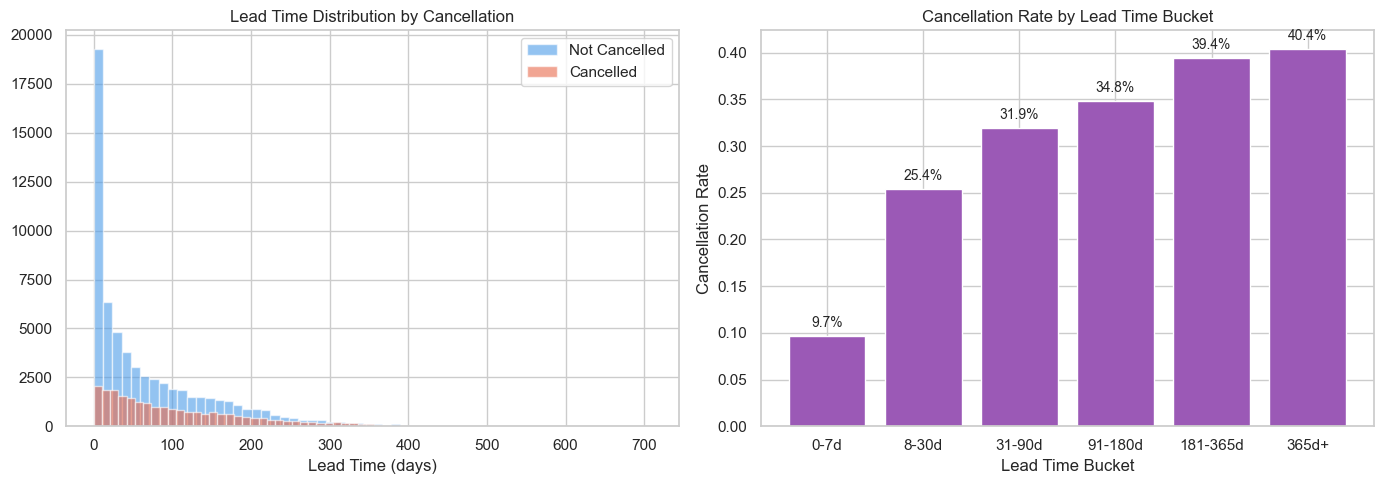

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lead time by cancellation
df[df["is_canceled"]==0]["lead_time"].hist(bins=60, alpha=0.6, label="Not Cancelled", 
                                            ax=axes[0], color="#4C9BE8")
df[df["is_canceled"]==1]["lead_time"].hist(bins=60, alpha=0.6, label="Cancelled", 
                                            ax=axes[0], color="#E8694C")
axes[0].set_title("Lead Time Distribution by Cancellation")
axes[0].set_xlabel("Lead Time (days)")
axes[0].legend()

# Cancellation rate by lead time bucket
df["lead_time_bucket"] = pd.cut(df["lead_time"], 
    bins=[0,7,30,90,180,365,737], 
    labels=["0-7d","8-30d","31-90d","91-180d","181-365d","365d+"])
lt_cancel = df.groupby("lead_time_bucket", observed=True)["is_canceled"].mean()
axes[1].bar(lt_cancel.index, lt_cancel.values, color="#9B59B6")
axes[1].set_title("Cancellation Rate by Lead Time Bucket")
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_xlabel("Lead Time Bucket")
for i, v in enumerate(lt_cancel.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("./reports/figures/03_lead_time.png", dpi=150)
plt.show()

## 6 — ADR distribution & price analysis

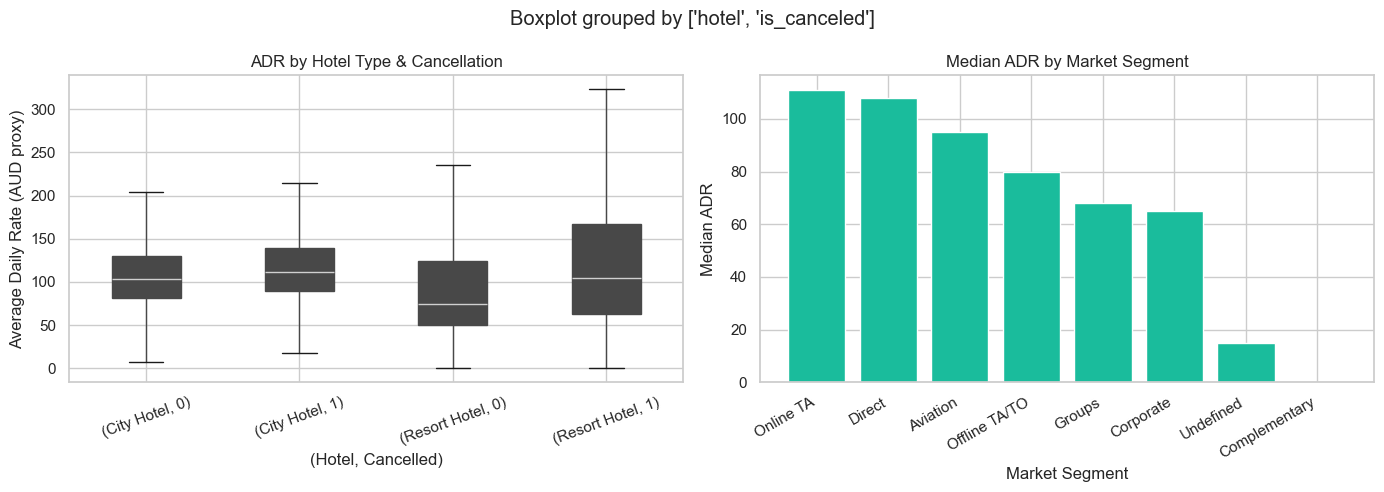

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADR by hotel type and cancellation
df.boxplot(column="adr", by=["hotel","is_canceled"], ax=axes[0], 
           patch_artist=True, showfliers=False)
axes[0].set_title("ADR by Hotel Type & Cancellation")
axes[0].set_xlabel("(Hotel, Cancelled)")
axes[0].set_ylabel("Average Daily Rate (AUD proxy)")
plt.sca(axes[0])
plt.xticks(rotation=20)

# ADR by market segment
seg_adr = df.groupby("market_segment")["adr"].median().sort_values(ascending=False)
axes[1].bar(seg_adr.index, seg_adr.values, color="#1ABC9C")
axes[1].set_title("Median ADR by Market Segment")
axes[1].set_ylabel("Median ADR")
axes[1].set_xlabel("Market Segment")
plt.sca(axes[1])
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("./reports/figures/04_adr_analysis.png", dpi=150)
plt.show()

## 7 — Deposit type & cancellation (strongest signal)

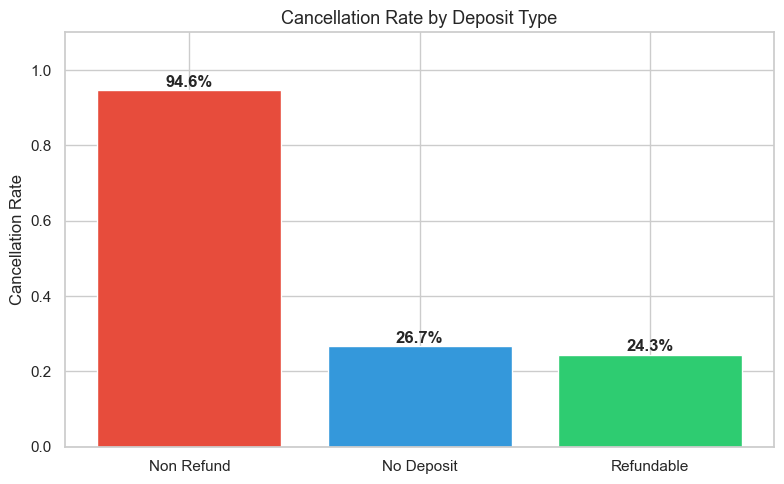

is_canceled          0         1
deposit_type                    
No Deposit    0.733261  0.266739
Non Refund    0.054081  0.945919
Refundable    0.757009  0.242991


In [15]:
deposit_cancel = df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(deposit_cancel.index, deposit_cancel.values, 
               color=["#E74C3C","#3498DB","#2ECC71"])
plt.title("Cancellation Rate by Deposit Type", fontsize=13)
plt.ylabel("Cancellation Rate")
for i, v in enumerate(deposit_cancel.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("./reports/figures/05_deposit_type.png", dpi=150)
plt.show()

print(df.groupby("deposit_type")["is_canceled"].value_counts(normalize=True).unstack())

## 8-Correlation heatmap

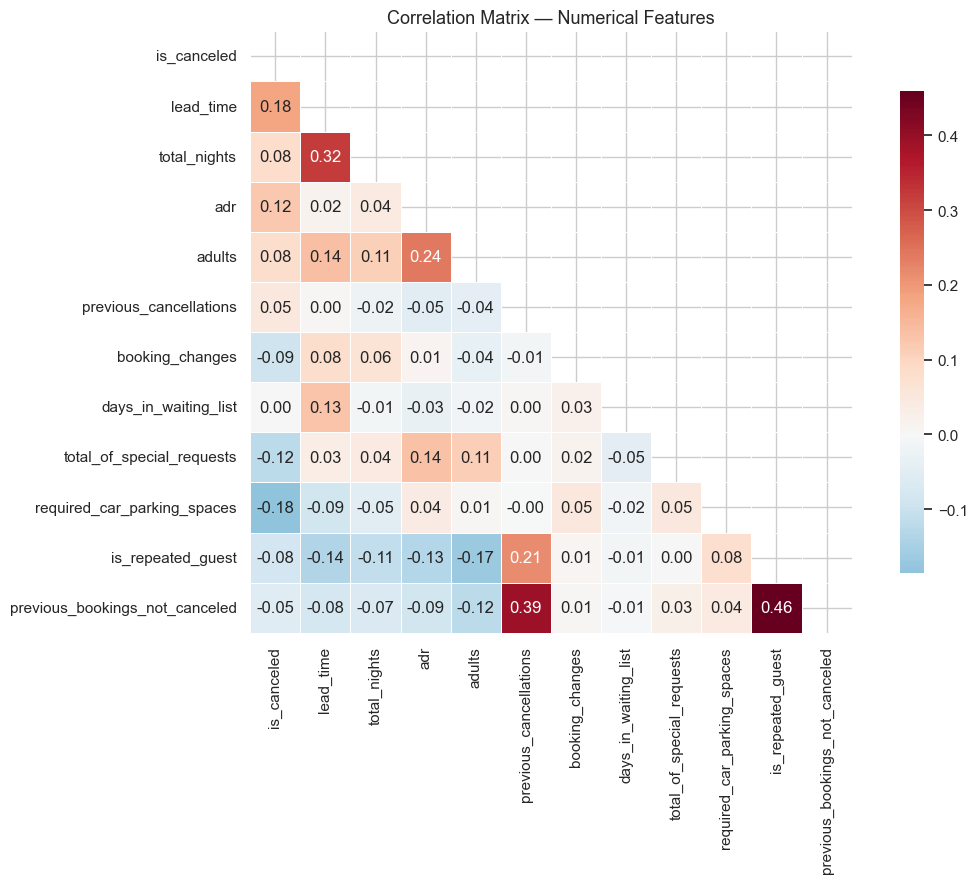

In [16]:
num_cols = ["is_canceled","lead_time","total_nights","adr","adults",
            "previous_cancellations","booking_changes","days_in_waiting_list",
            "total_of_special_requests","required_car_parking_spaces",
            "is_repeated_guest","previous_bookings_not_canceled"]

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numerical Features", fontsize=13)
plt.tight_layout()
plt.savefig("./reports/figures/06_correlation_heatmap.png", dpi=150)
plt.show()